In [9]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


In [14]:
class tree_family():
    def __init__(self, df):
        self.df = pd.read_csv(df)
    def split_df_X_Y(self, name_of_column):
        self.x = self.df.drop(name_of_column,axis=1)
        self.y = self.df[name_of_column]
    def split_train_test(self,test_size=0.3):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(self.x, self.y, test_size=test_size, stratify=None,random_state=42)
    def DecisionTreeClassifier(self,max_depth=4, bool_save = True):
        

        print("DecisionTreeClassifier\n\n")
        clf = DecisionTreeClassifier(random_state = 42,max_depth = max_depth)
        clf.fit(self.x_train, self.y_train)
        prediction = clf.predict(self.x_test)
        tree_family.metrix(self,prediction, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/DecisionTreeClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")

    def RandomForestClassifier(self,n_estimators=200,max_depth = 4,bool_save = True):
        
        print("RandomForestClassifier\n\n")

        clf = RandomForestClassifier(n_estimators=n_estimators,random_state = 42,max_depth = max_depth)
        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/RandomForestClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")
    def GradientBoostingClassifier(self, n_estimators=200, max_depth=3, bool_save = True):
        
        print("GradientBoostingClassifier\n\n")


        clf = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        # Создаем веса для каждой строки обучающей выборки
        # weights = y_train.iloc[:, 0].map({0: 1, 1: 6})


        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/GradientBoostingClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")


    def metrix(self,prediction,clf):
        from sklearn.model_selection import cross_val_score
        accuracy_score(prediction, self.y_test)
        print(f"Accuracy:{accuracy_score(self.y_test, prediction):.3f}")
        print(f"Precision:{precision_score(self.y_test, prediction):.3f}")
        print(f"Recall:  {recall_score(self.y_test, prediction):.3f}")
        print(f"F1-score: {f1_score(self.y_test, prediction):.3f}")
        # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
        print("\nConfusion Matrix:\n", confusion_matrix(self.y_test, prediction))
        print("\nClassification Report:\n", classification_report(self.y_test, prediction))


        scores_f1 = cross_val_score(clf, self.x, self.y, cv=5, scoring='f1')

        print(f"F1-результаты по фолдам: {scores_f1}")
        print(f"Средний F1: {scores_f1.mean():.2f}")
        from sklearn import metrics
        fpr, tpr, _ = metrics.roc_curve(self.y_test,  prediction)

        # построение ROC кривой
        plt.plot(fpr, tpr)
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.show()
        return

DecisionTreeClassifier


Accuracy:0.884
Precision:0.804
Recall:  0.974
F1-score: 0.881

Confusion Matrix:
 [[39  9]
 [ 1 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.89        48
           1       0.80      0.97      0.88        38

    accuracy                           0.88        86
   macro avg       0.89      0.89      0.88        86
weighted avg       0.90      0.88      0.88        86

F1-результаты по фолдам: [0.4        0.64150943 0.77777778 0.71186441 0.70833333]
Средний F1: 0.65


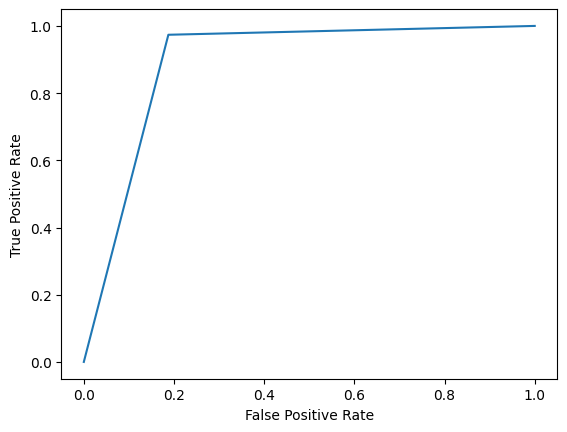

SAVE TURN OFF
RandomForestClassifier


Accuracy:0.942
Precision:0.902
Recall:  0.974
F1-score: 0.937

Confusion Matrix:
 [[44  4]
 [ 1 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        48
           1       0.90      0.97      0.94        38

    accuracy                           0.94        86
   macro avg       0.94      0.95      0.94        86
weighted avg       0.94      0.94      0.94        86

F1-результаты по фолдам: [0.1875     0.75555556 0.63636364 0.45       0.06896552]
Средний F1: 0.42


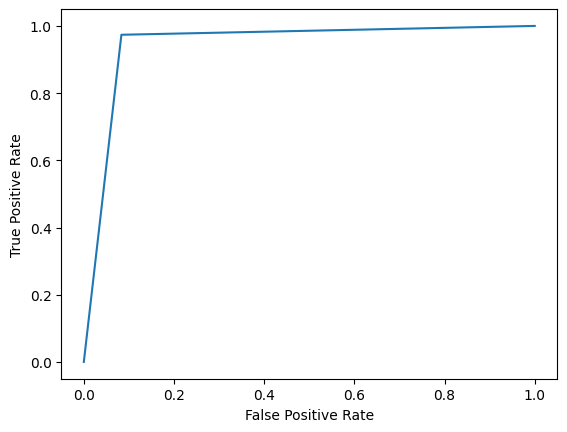

SAVE TURN OFF
GradientBoostingClassifier


Accuracy:0.907
Precision:0.841
Recall:  0.974
F1-score: 0.902

Confusion Matrix:
 [[41  7]
 [ 1 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91        48
           1       0.84      0.97      0.90        38

    accuracy                           0.91        86
   macro avg       0.91      0.91      0.91        86
weighted avg       0.92      0.91      0.91        86

F1-результаты по фолдам: [0.62222222 0.64150943 0.72       0.75862069 0.60465116]
Средний F1: 0.67


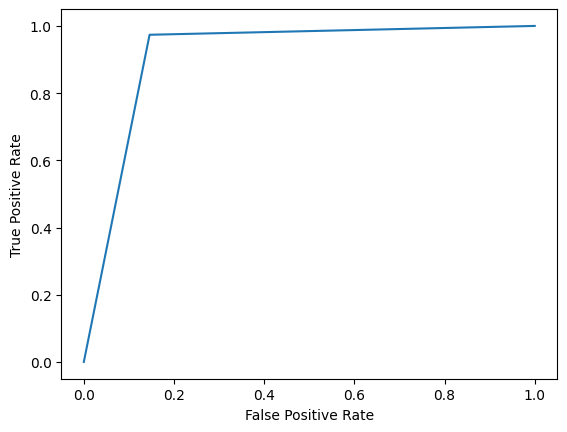

SAVE TURN OFF


In [16]:
EGG_data_spliting_with_new_1_category = tree_family(r"/home/ikuku/UDGU_project/main/EEG_files/data_for_EEG/df_with_new_1_category_EEG.csv")
EGG_data_spliting_with_new_1_category.split_df_X_Y("здоров(1)/болен(0)")
EGG_data_spliting_with_new_1_category.split_train_test()
EGG_data_spliting_with_new_1_category.DecisionTreeClassifier(max_depth = 12,bool_save = False)
EGG_data_spliting_with_new_1_category.RandomForestClassifier(n_estimators= 300,max_depth = 12,bool_save = False)
EGG_data_spliting_with_new_1_category.GradientBoostingClassifier(n_estimators = 300,max_depth = 12,bool_save = False)

In [ ]:
df = pd.read_csv(r"/home/ikuku/UDGU_project/main/EEG_files/data_for_EEG/df_with_new_1_category_EEG.csv")

In [ ]:
df.info(verbose=True)


<class 'pandas.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 1472 columns):
 #     Column              Dtype  
---    ------              -----  
 0     Имя                 str    
 1     D_1:2               float64
 2     D_1:3               float64
 3     D_1:4               float64
 4     D_1:5               float64
 5     D_1:6               float64
 6     D_1:7               float64
 7     D_1:8               float64
 8     D_1:9               float64
 9     D_1:10              float64
 10    D_1:11              float64
 11    D_1:12              float64
 12    D_1:13              float64
 13    D_1:14              float64
 14    D_1:15              float64
 15    D_1:16              float64
 16    D_1:17              float64
 17    D_1:18              float64
 18    D_1:19              float64
 19    D_1:20              float64
 20    D_1:21              float64
 21    D_2:3               float64
 22    D_2:4               float64
 23    D_2:5               fl